# Coletando o theta estimado

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmbrl.model import *
from pmbrl.data import *
from pmbrl.experiment import *

import gymnasium as gym
import rlenvs

In [2]:
n_episodes = 100

# env = gym.make("custom/DiscreteCartPole-v1")
env = gym.make("custom/CartPole-v1")

data = [generate_episode(env=env, seed=i) for i in range(n_episodes)]
# for i in data:
#     print(i.shape)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


In [24]:
# for epi in data:
#     print(epi[0])

In [4]:
n_agents = 1

pmbrl = [Model(learning_rate=[0.0001,0.001]) for _ in range(n_agents)]
# mbrl = [ModelBase(learning_rate=[0.0001,0.001]) for _ in range(n_agents)]

In [5]:
training = { # Traning:
    "mode": "all", # Mode of the PMBRL (All: learn parameters and Transitions)
    "debug": False, # Number of epochs on training
    "num_epochs": 5000, # Number of epochs on training
}

def run(data, models, val=200, verbose=False):
    results = []
    dataset = np.concat(data, axis=0)
    X, y = train_data(build_data(dataset))
    
    for j, agent in enumerate(models):
        if verbose:
            print(f'Agent {j}...')
        agent.train(X[:-val], y[:-val, :-2], **training)
        s,r = agent.sample(X[-val:], mode=training['mode'])
        p,_ = agent.sample(X[-val:, :-1], mode='param')
        results = torch.concat([
                torch.tensor([j]*val).unsqueeze(1),
                (torch.mean((s - y[-val:,:2])**2, axis=0)**.5).repeat(val, 1),
                (torch.mean((r - y[-val:,2])**2, axis=0)**.5).unsqueeze(1),
                p,
                y[-val:, 3:]
            ], axis=1)

    return pd.DataFrame(np.array(results), columns=['agent', 's_0', 's_1', 'r', 'p_0', 'p_1', 'reff_p_0', 'reff_p_1']) 

# pmbrl_results = run(data, pmbrl)
# mbrl_results = run(data, mbrl)

In [6]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

# pmbrl_plot = pmbrl_results.groupby(by='epi').median()[['s_0','s_1','r', 'p_0', 'p_1']]

Training pmbrl...
Agent 0...
pmbrl done!


In [7]:
# print('Training mbrl...')
# mbrl_results = run(data, mbrl, verbose=True)
# print('mbrl done!')

# mbrl_plot = mbrl_results.groupby(by='epi').median()[['s_0','s_1','r', 'p_0', 'p_1']]

In [8]:
def add_plot(name, d, axis, reffs):
    # reff = np.zeros(data.shape[0])
    axis[0].set_ylabel(name)
    axis[0].set_ylabel(name)

    axis[0].plot(d['p_0'], color = 'g')
    axis[0].plot(reffs[0], linestyle = 'dotted', color = 'g')
    axis[0].set_yticks(np.arange(5) - 2)

    axis[1].plot(d['p_1'], color = 'b')
    axis[1].plot(reffs[1], linestyle = 'dotted', color = 'b')
    axis[1].set_yticks(np.arange(5) - 2)


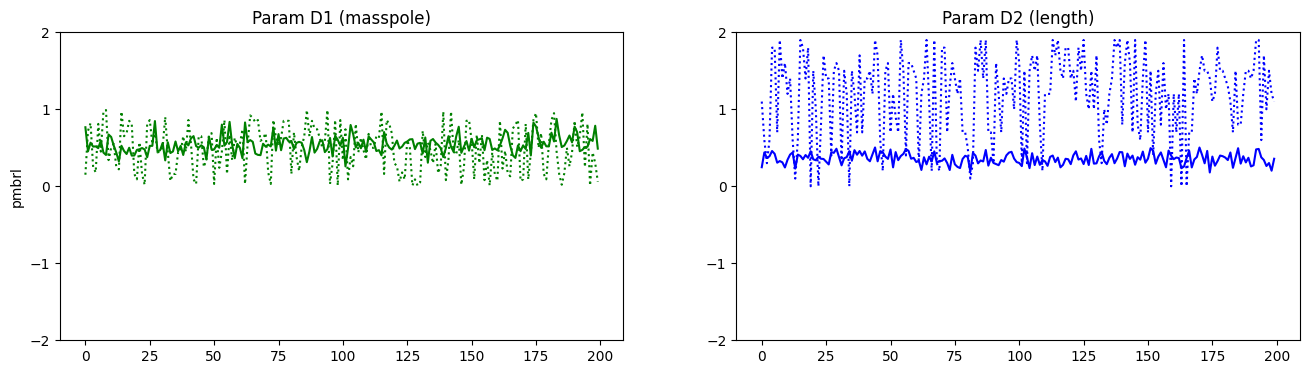

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].set_title('Param D1 (masspole)')
axs[1].set_title('Param D2 (length)')

add_plot(f'pmbrl', pmbrl_results, axs, (pmbrl_results.reff_p_0, pmbrl_results.reff_p_1))

plt.show()

# Teste

In [10]:
n_episodes = 10

env = gym.make("custom/CartPole-v1")
data = [generate_episode(env=env) for _ in range(n_episodes)]

for i in data:
    print(i.shape)

(20, 8)
(23, 8)
(9, 8)
(7, 8)
(24, 8)
(24, 8)
(26, 8)
(4, 8)
(46, 8)
(39, 8)


/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


In [11]:
def run(data, models, verbose=False):
    results = []
    for i, epi in enumerate(data):
        if verbose:
            print(f'Episode {i}...')
        X, y = build_train_data(epi)
        for j, agent in enumerate(models):
            if verbose:
                print(f'Agent {j}...')
            for k, (feature, target) in enumerate(zip(X,y)):
                s,r = agent.sample(torch.unsqueeze(feature, axis=0), mode=training['mode'])
                p,_ = agent.sample(torch.unsqueeze(feature, axis=0)[:, :-1], mode='param')
                results.append(
                    torch.concat([
                        torch.tensor([i, j, k]),
                        torch.mean((s - target[:2])**2, axis=0)**.5,
                        torch.mean((r - target[2])**2, axis=0)**.5,
                        p[0],
                        y[-1, 3:]
                ], axis=0)
            )
    return pd.DataFrame(np.array(results), columns=['epi', 'agent', 'step', 's_0', 's_1', 'r', 'p_0', 'p_1', 'reff_p_0', 'reff_p_1']) 


In [12]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

# pmbrl_plot = pmbrl_results.groupby(by='step').mean()[['s_0','s_1','r', 'p_0','p_1']]

Training pmbrl...
Episode 0...
Agent 0...
Episode 1...
Agent 0...
Episode 2...
Agent 0...
Episode 3...
Agent 0...
Episode 4...
Agent 0...
Episode 5...
Agent 0...
Episode 6...
Agent 0...
Episode 7...
Agent 0...
Episode 8...
Agent 0...
Episode 9...
Agent 0...
pmbrl done!


In [13]:
pmbrl_plot = pmbrl_results[pmbrl_results['epi']==0.0]#.groupby(by='step').mean()[['s_0','s_1','r', 'p_0','p_1']]
pmbrl_plot

,epi,agent,step,s_0,s_1,r,p_0,p_1,reff_p_0,reff_p_1
0,0.0,0.0,0.0,0.010487,0.057004,0.018058,0.534126,0.317964,0.11,0.6
1,0.0,0.0,1.0,0.013918,0.155579,0.018598,0.509584,0.306966,0.11,0.6
2,0.0,0.0,2.0,0.016637,0.246673,0.019493,0.481358,0.300570,0.11,0.6
3,0.0,0.0,3.0,0.021066,0.489013,0.019584,0.449333,0.298751,0.11,0.6
4,0.0,0.0,4.0,0.009323,0.505560,0.020725,0.434661,0.396387,0.11,0.6
5,0.0,0.0,5.0,0.003302,0.347297,0.021588,0.444610,0.424537,0.11,0.6
6,0.0,0.0,6.0,0.001888,0.199389,0.022119,0.457507,0.448069,0.11,0.6
7,0.0,0.0,7.0,0.006188,0.065703,0.022280,0.473453,0.467099,0.11,0.6
8,0.0,0.0,8.0,0.011890,0.101001,0.023204,0.492556,0.481698,0.11,0.6
9,0.0,0.0,9.0,0.002359,0.141050,0.023229,0.495118,0.395737,0.11,0.6


In [14]:
# print('Training mbrl...')
# mbrl_results = run(data, mbrl, verbose=True)
# print('mbrl done!')

# mbrl_plot = mbrl_results.groupby(by='step').mean()[['s_0','s_1','r']]

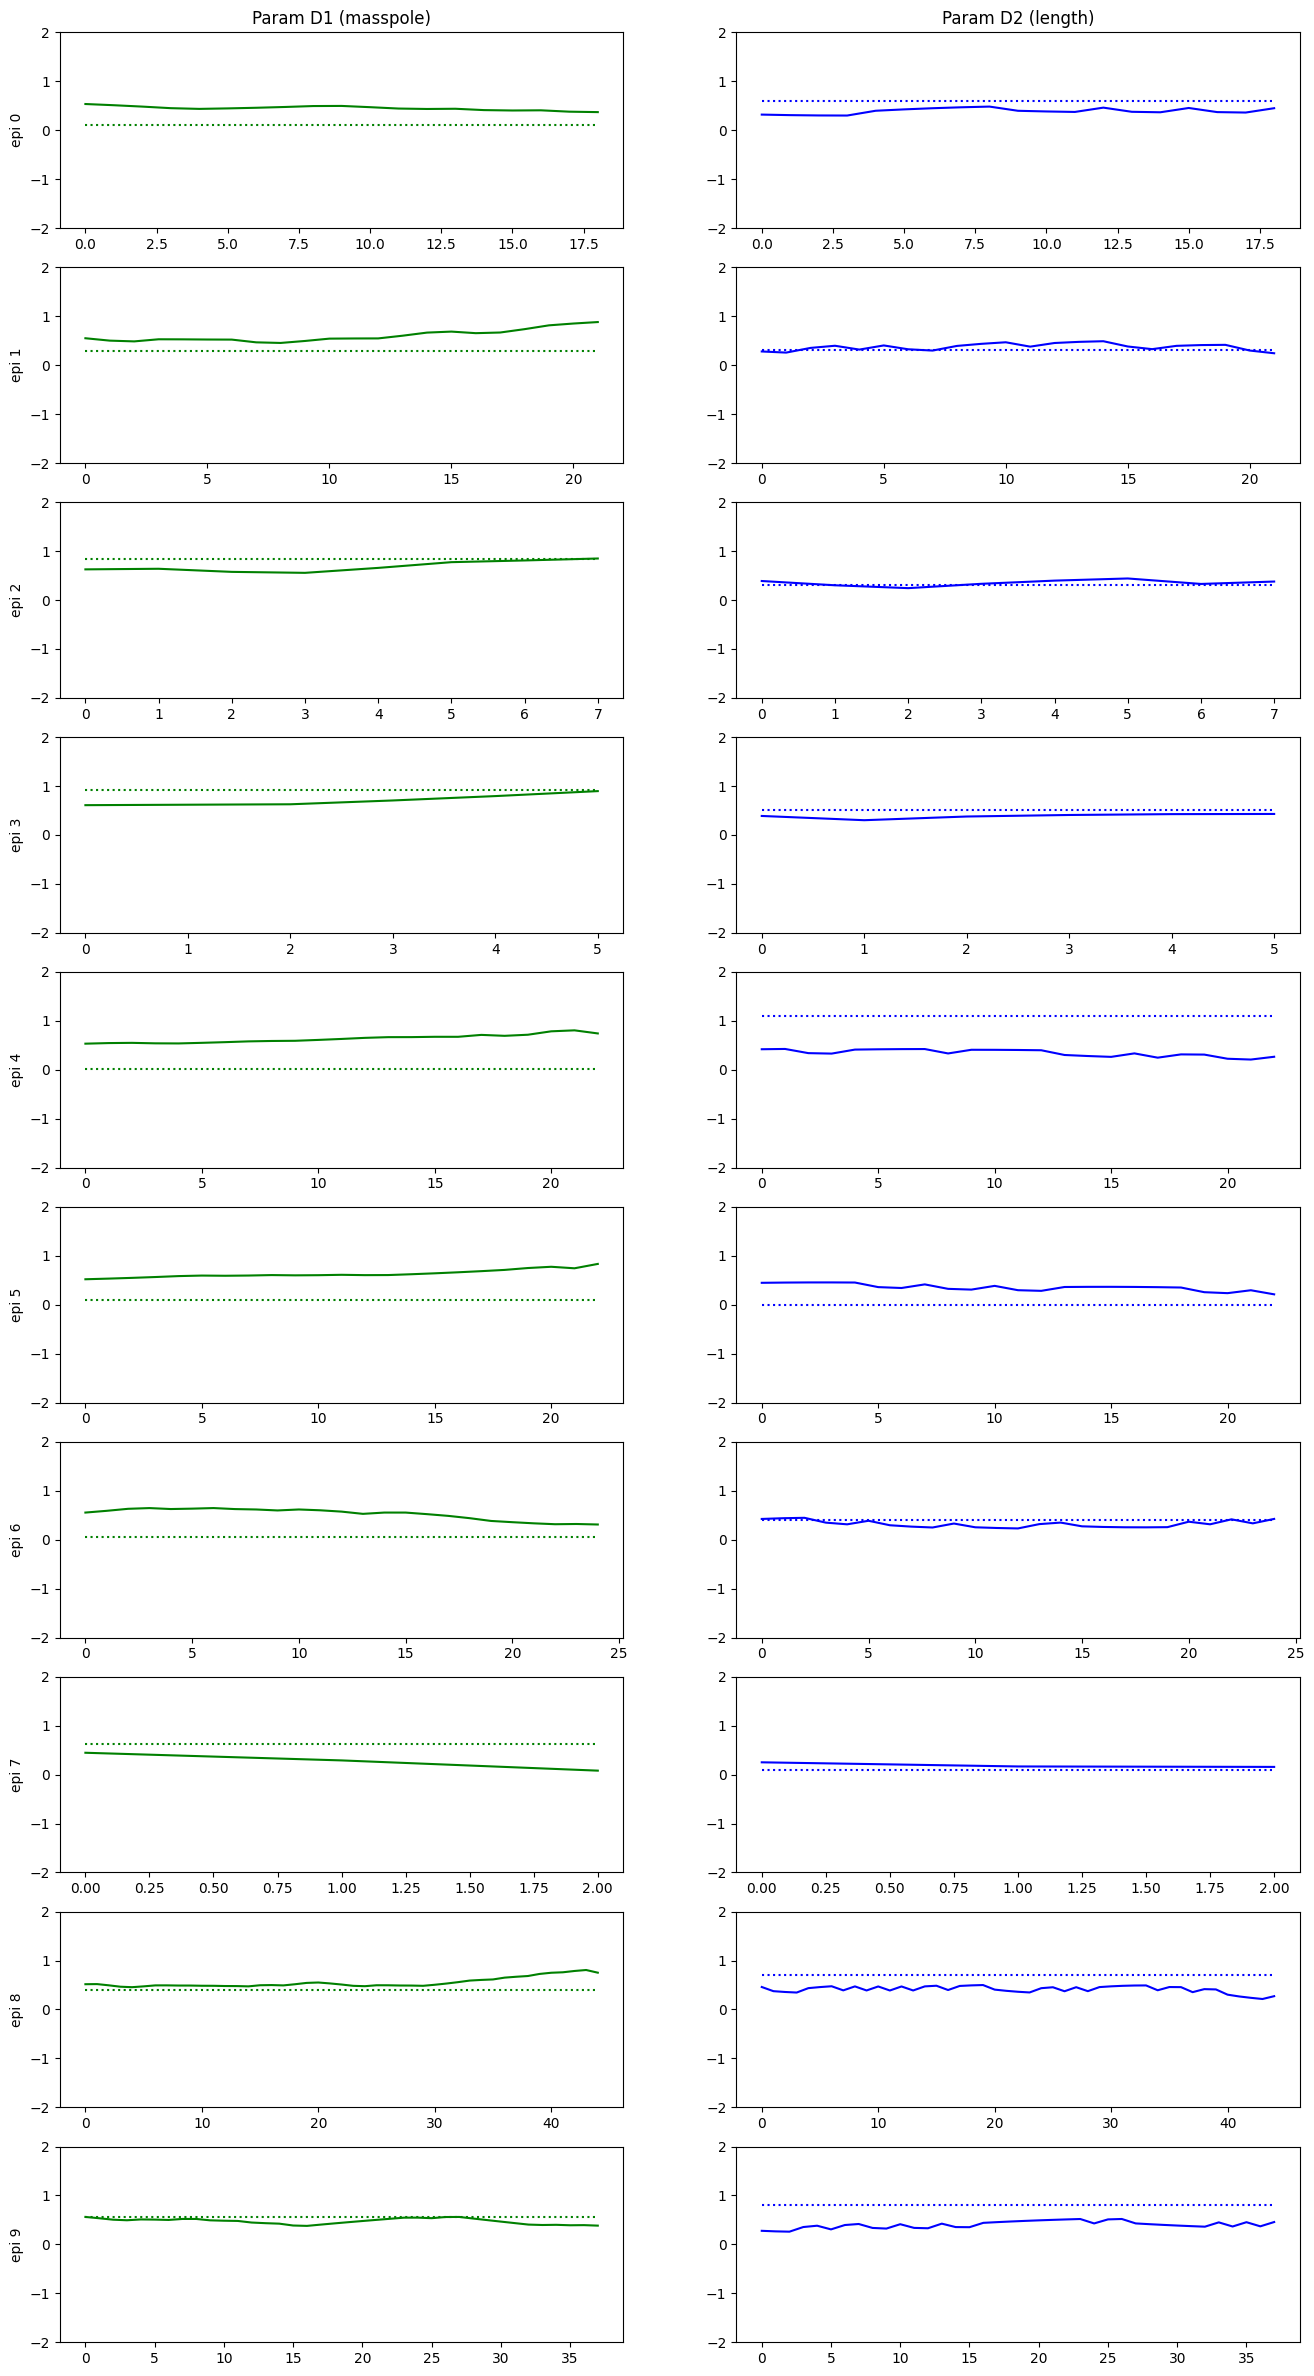

In [15]:
n = pmbrl_results.epi.drop_duplicates().size

fig, axs = plt.subplots(n, 2, figsize=(16, n*3))

axs[0][0].set_title('Param D1 (masspole)')
axs[0][1].set_title('Param D2 (length)')


for i in range(n):
    add_plot(
        f'epi {i}', 
        pmbrl_results[pmbrl_results.epi==i].reset_index(), 
        axs[i], 
        (
            pmbrl_results[pmbrl_results.epi==i].reset_index().reff_p_0, 
            pmbrl_results[pmbrl_results.epi==i].reset_index().reff_p_1
        )
    )

plt.show()

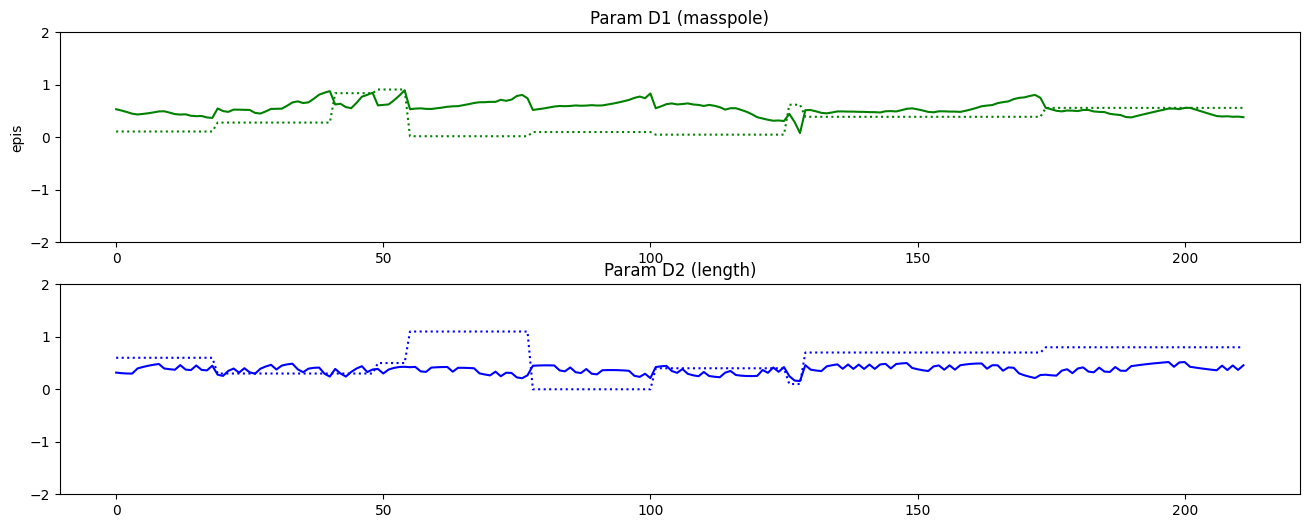

In [16]:
n = pmbrl_results.epi.drop_duplicates().size

fig, axs = plt.subplots(2, 1, figsize=(16, 6))

axs[0].set_title('Param D1 (masspole)')
axs[1].set_title('Param D2 (length)')


add_plot(
    f'epis', 
    pmbrl_results.reset_index(), 
    axs, 
    (
        pmbrl_results.reset_index().reff_p_0, 
        pmbrl_results.reset_index().reff_p_1
    )
)

plt.show()

In [23]:
pmbrl_results[pmbrl_results.step == 0].describe()

,epi,agent,step,s_0,s_1,r,p_0,p_1,reff_p_0,reff_p_1
count,10.00000,10.0,10.0,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,4.50000,0.0,0.0,0.011630,0.525433,0.017342,0.544701,0.364947,0.388000,0.480000
std,3.02765,0.0,0.0,0.012142,1.034257,0.001969,0.049813,0.077340,0.330279,0.332666
min,0.00000,0.0,0.0,0.000903,0.050791,0.014674,0.445529,0.250382,0.020000,0.000000
25%,2.25000,0.0,0.0,0.003455,0.076205,0.015945,0.523983,0.287936,0.102500,0.300000
50%,4.50000,0.0,0.0,0.009339,0.185779,0.017247,0.541269,0.387434,0.335000,0.450000
75%,6.75000,0.0,0.0,0.013540,0.314875,0.018635,0.559138,0.422476,0.605000,0.675000
max,9.00000,0.0,0.0,0.042574,3.434896,0.020983,0.625731,0.459267,0.910000,1.100000
